In [23]:
import numpy as np
import json
from pathlib import Path
from matplotlib import pyplot as plt

from usecases.utils.test_nb_functions import plot_multiple_responses, rmse_complex, transfer_function

## Чтение данных из csv-файлов

Директория с файлами и имена.

In [24]:
sample_dir = Path("usecases/test_samples/experiments_13_May_2026")

sample_file_name_list = [
    "Zout_300_AP",
    "Zouti_300_AP",
    "Wui_300_DP",
    "Wui_delay_300_DP",
    "G_I_PID_300_DP",
    "G_U_PI_300_DP",
    "G_I_PI_300_DP"
    ]
ext = '.csv'

data_list = []
for sample_file_name in sample_file_name_list:
    data_list.append(np.loadtxt(sample_dir / (sample_file_name + ext), delimiter=',', skiprows=1).T)

Интерполяция данных.

In [25]:
data_list_interp = []
for data in data_list:
    freq = data[0,:]
    mag_ph = np.array([data[1,:], data[2,:]])

    freq_log = np.logspace(np.log10(freq.min()), np.log10(freq.max()), num=512)
    mag_ph_interp = np.array([np.interp(freq_log, freq, y) for y in mag_ph])
    data_interp = np.vstack((freq_log, mag_ph_interp))
    data_list_interp.append(data_interp)
data_list = data_list_interp.copy()

Координаты полюсов/нулей.

In [26]:
approx_source_list = ['calc', 'model']

zeros_poles_list_calc = [
    {
    "left_poles": [],
    "right_poles": [],
    "left_zeros": [25e3],
    "right_zeros": [],
    "zero_poles": 1,
    "gain": 230.0,
    "delay": 0.0
    },
    {
    "left_poles": [39],
    "right_poles": [],
    "left_zeros": [25e3],
    "right_zeros": [],
    "zero_poles": 0,
    "gain": 0.9,
    "delay": 0.0
    },
    {
    "left_poles": [39],
    "right_poles": [],
    "left_zeros": [25e3],
    "right_zeros": [5.5e3],
    "zero_poles": 0,
    "gain": 4.0,
    "delay": 0e-6
    },
    {
    "left_poles": [39],
    "right_poles": [],
    "left_zeros": [25e3],
    "right_zeros": [5.5e3],
    "zero_poles": 0,
    "gain": 4.0,
    "delay": 10e-6
    },
    {
    "left_poles": [42e3],
    "right_poles": [],
    "left_zeros": [380, 17e3],
    "right_zeros": [],
    "zero_poles": 1,
    "gain": 3550.0,
    "delay": 0.0
    },
    {
    "left_poles": [],
    "right_poles": [],
    "left_zeros": [270],
    "right_zeros": [],
    "zero_poles": 1,
    "gain": 3500.0,
    "delay": 0.0
    },
    {
    "left_poles": [],
    "right_poles": [],
    "left_zeros": [1.5e3],
    "right_zeros": [],
    "zero_poles": 1,
    "gain": 8250.0,
    "delay": 0.0
    }    
]


zeros_poles_list_model = [
    {
    "left_poles": [],
    "right_poles": [],
    "left_zeros": [27380.59767508],
    "right_zeros": [],
    "zero_poles": 1,
    "gain": 230.0,
    "delay": 0.0
    },
    {
    "left_poles": [37.81999785],
    "right_poles": [],
    "left_zeros": [26929.07309274],
    "right_zeros": [],
    "zero_poles": 0,
    "gain": 0.9,
    "delay": 0.0
    },
    {
    "left_poles": [31.49813163],
    "right_poles": [],
    "left_zeros": [],
    "right_zeros": [5457.02075224],
    "zero_poles": 0,
    "gain": 4.4,
    "delay": 0e-6
    },
    {
    "left_poles": [32.56325657],
    "right_poles": [],
    "left_zeros": [],
    "right_zeros": [5457.02075224],
    "zero_poles": 0,
    "gain": 4.4,
    "delay": 10e-6
    },
    {
    "left_poles": [],
    "right_poles": [],
    "left_zeros": [356.96573531, 16905.14422159],
    "right_zeros": [],
    "zero_poles": 1,
    "gain": 3550.0,
    "delay": 0.0
    },
    {
    "left_poles": [],
    "right_poles": [],
    "left_zeros": [260.26614205],
    "right_zeros": [],
    "zero_poles": 1,
    "gain": 3300.0,
    "delay": 0.0
    },
    {
    "left_poles": [],
    "right_poles": [],
    "left_zeros": [1467.08617405],
    "right_zeros": [],
    "zero_poles": 1,
    "gain": 8250.0,
    "delay": 0.0
    }    
]

## Визуализация

In [27]:
with open('usecases/plot_config.json', 'r', encoding='utf-8') as f:
    PLOT_CONFIG = json.load(f)

calc


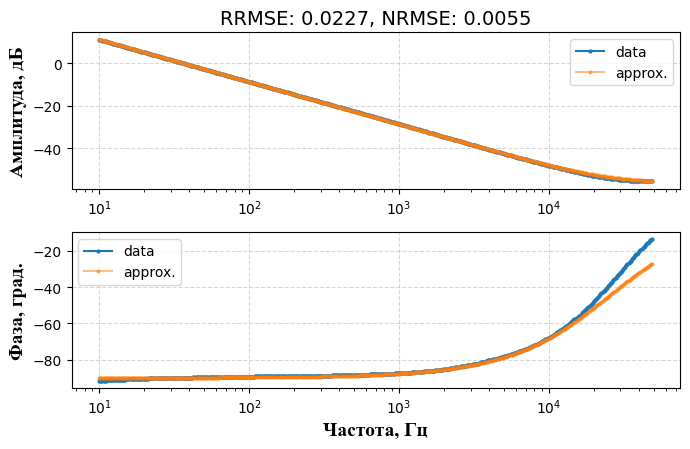

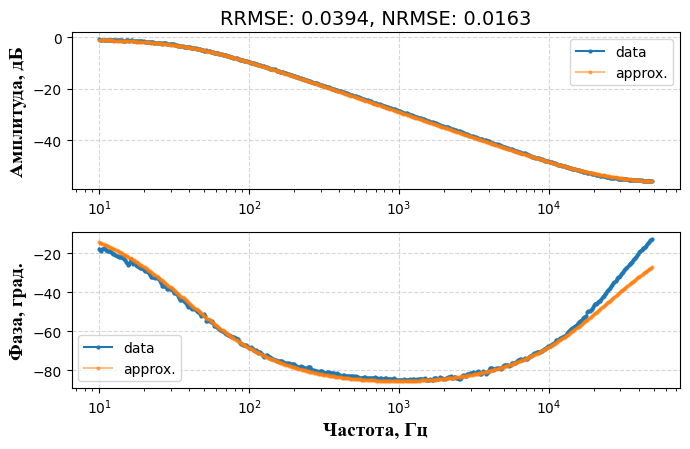

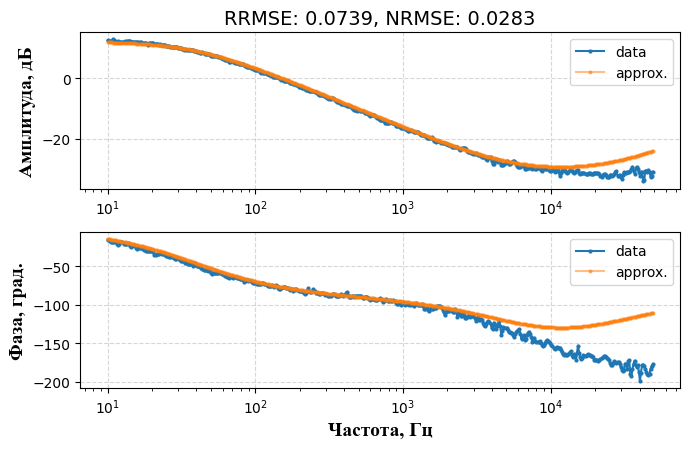

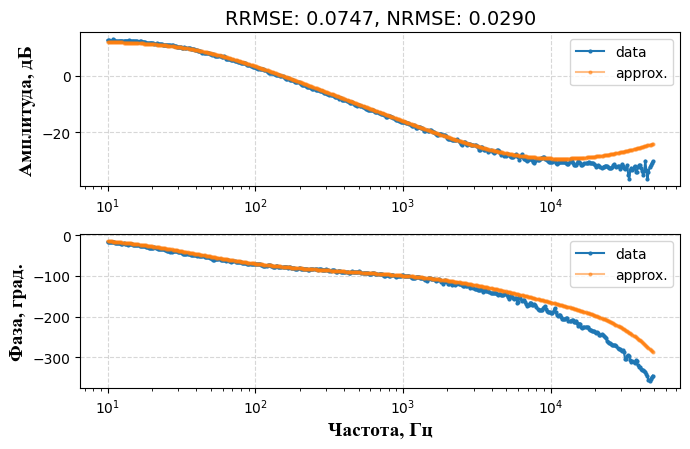

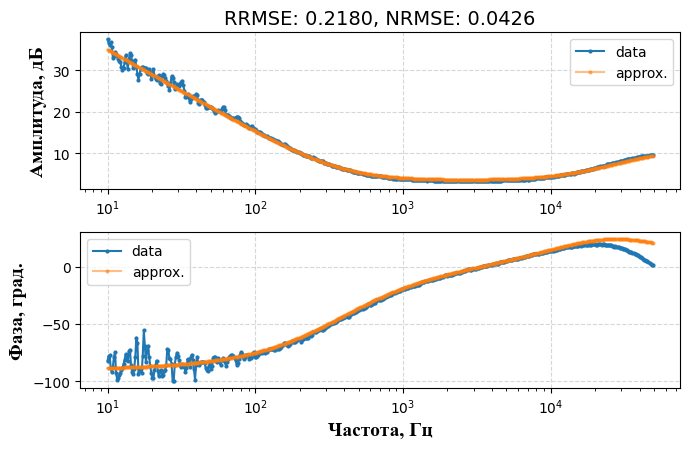

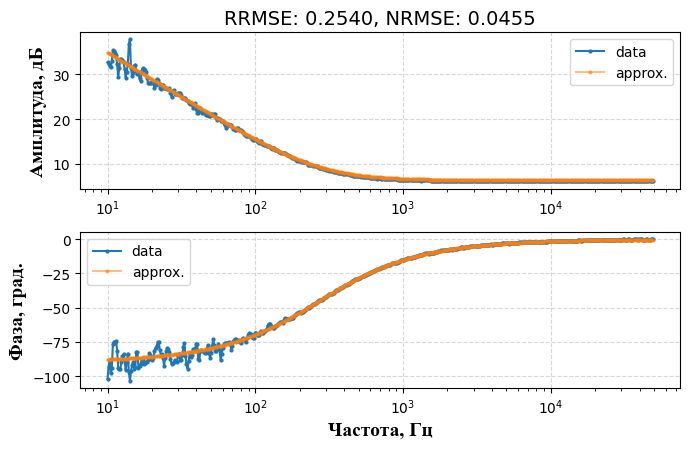

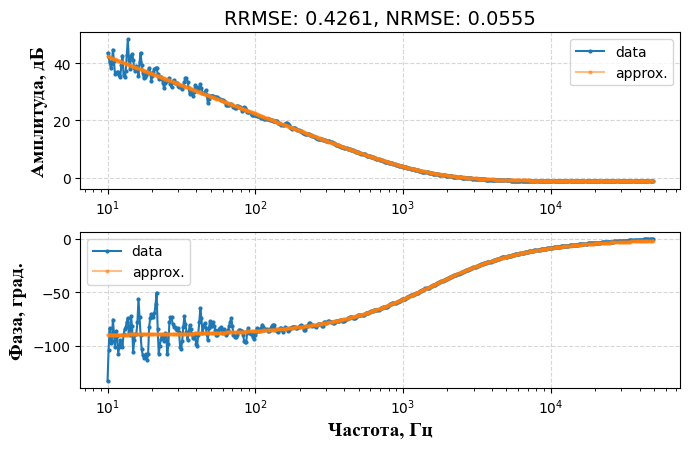

model


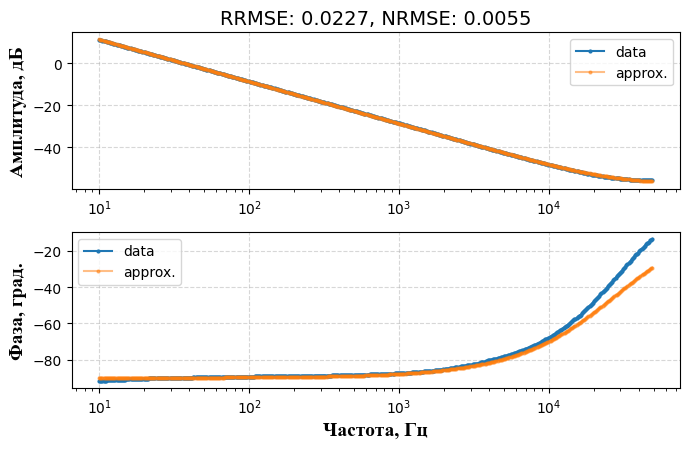

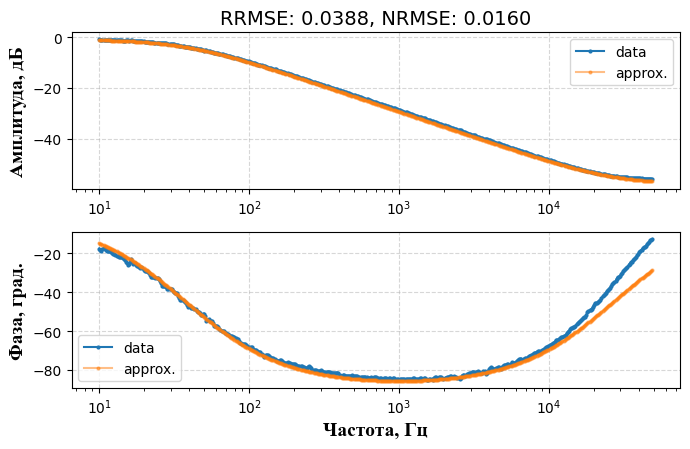

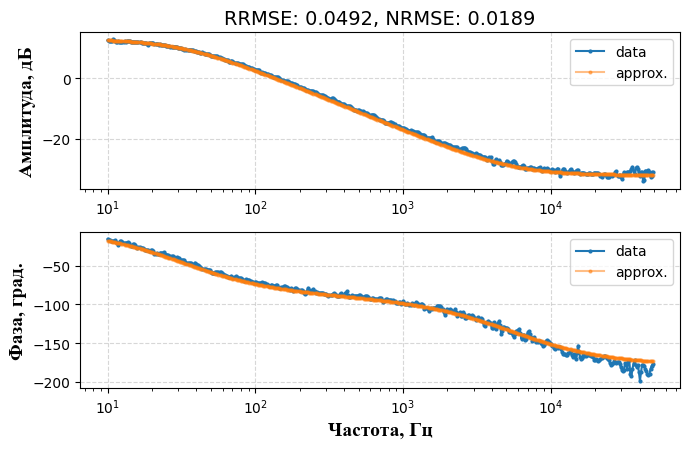

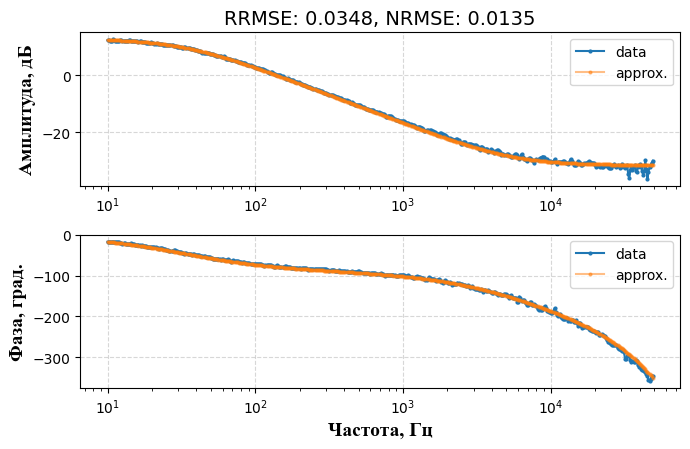

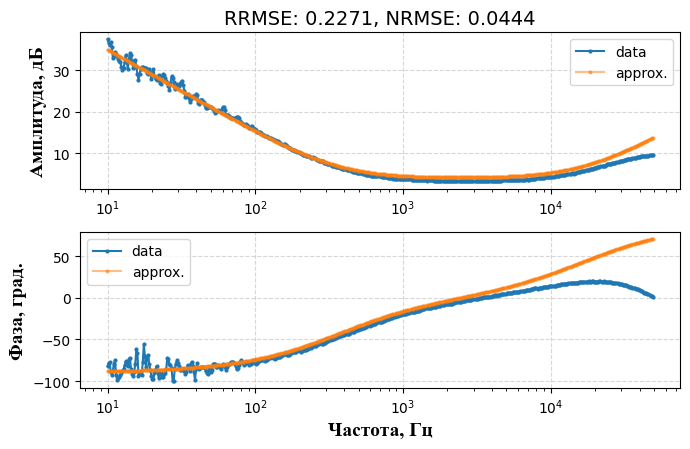

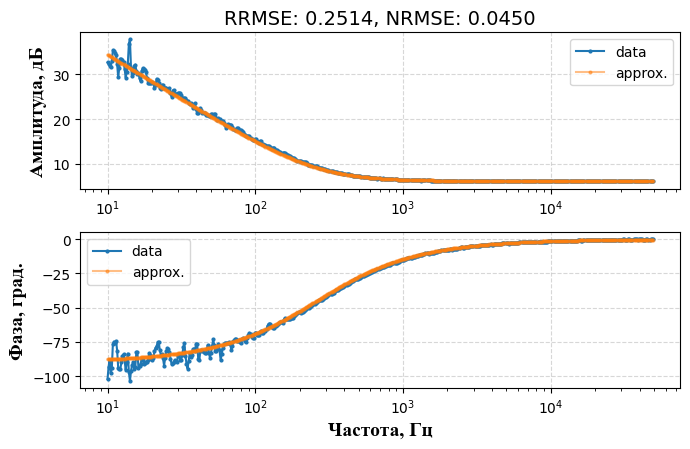

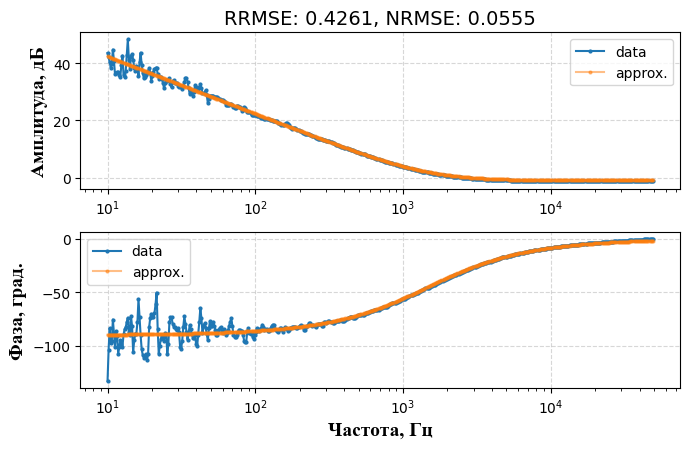

In [28]:
for approx_source, zeros_poles_list in zip(approx_source_list, [zeros_poles_list_calc, zeros_poles_list_model]):
    print(approx_source)
    for mask, data, zeros_poles, sample_file_name in zip(
        zeros_poles_list,
        data_list,
        zeros_poles_list,
        sample_file_name_list
        ):
        freq = data[0,:]
        gain_complex = transfer_function(
                freq=freq,
                zero_poles=mask["zero_poles"],
                poles=mask["left_poles"] + (-1 * np.array(mask["right_poles"])).tolist(),
                zeros=mask["left_zeros"] + (-1 * np.array(mask["right_zeros"])).tolist(),
                gain=mask["gain"],
                delay=mask["delay"]
                )
        magnitude = 20*np.log10(np.abs(gain_complex))
        phase = 180 / np.pi * np.unwrap(np.angle(gain_complex))
        estim = np.array([freq, magnitude, phase])
        _, RRMSE, NRMSE = rmse_complex(
            response_in=estim,
            response_ref=data
            #Nlim=[100, None]
            )

        plot_multiple_responses(
            plot_config=PLOT_CONFIG,
            data_list=[data, estim],
            legend=["data", "approx."],
            title=f'RRMSE: {RRMSE:.4f}, NRMSE: {NRMSE:.4f}',
            save_path=f'usecases/test_samples/experiments_13_May_2026/pdf/fr_approx_{approx_source}_{sample_file_name}.pdf'
            )